# Data cleaning with FastDup

This notebook shows how to quickly analyze an image dataset for potential issues using `fastdup`.   
By the end of this notebook you will learn how to find out if your dataset has issues such as:

+ Broken images.
+ Duplicates/near-duplicates.
+ Outliers.
+ Dark/bright/blurry images.

We'll also visualize clusters of visually similar looking images to let you have a birds eye view on your dataset.

## Import necessary libraries and download dataset

**NOTE:** `fastdup` sometimes has some compatibility issues with different platforms https://github.com/visual-layer/fastdup/issues/65

In [1]:
!pip install fastdup -Uq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.3/92.3 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.2/189.2 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.9/75.9 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.2/133.2 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.3/88.3 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 58.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.4/28.4 MB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.9/38.9 MB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.8/62.8 k

Now, test the installation by printing out the version. If there's no error message, we are ready to go!

In [2]:
try:
    import google.colab

    IN_COLAB = True
except:
    IN_COLAB = False

import os

IN_KAGGLE = "KAGGLE_KERNEL_RUN_TYPE" in os.environ

In [3]:
import sys
from pathlib import Path

import fastdup
from torchvision import datasets, transforms

if IN_COLAB or IN_KAGGLE:
    !git clone https://github.com/Digital-Dermatology/data-cleaning-hands-on.git
    sys.path.append("data-cleaning-hands-on")
else:
    sys.path.append("../")

from utils import get_oxford_pets3t, get_imagenette

fastdup.__version__

Cloning into 'data-cleaning-hands-on'...
remote: Enumerating objects: 211, done.
remote: Counting objects: 100% (113/113), done.
remote: Compressing objects: 100% (80/80), done.
remote: Total 211 (delta 50), reused 80 (delta 27), pack-reused 98 (from 1)
Receiving objects: 100% (211/211), 87.93 MiB | 25.91 MiB/s, done.
Resolving deltas: 100% (92/92), done.
Filtering content: 100% (6/6), 685.16 MiB | 49.20 MiB/s, done.


'2.13'

We start by downloading our dataset to analyze.   
**NOTE:** FastDup only requires the path to the images.

You can analyze either Oxford PetIIIT:

In [ ]:
# dataset_name = "OxfordIIITPet"
# data_path = Path("../data/") / dataset_name
# _, df = get_oxford_pets3t(
    # root_path=data_path, return_dataframe=True, transform=transforms.Resize((256, 256))
# )
# df.drop(columns=["label"], inplace=True)
# df.rename(columns={"img_path": "filename", "label_name": "label"}, inplace=True)

or ImageNette:

In [4]:
dataset_name = "ImageNette"
data_path = Path("../data/")
_, df = get_imagenette(
   root_path=data_path, return_dataframe=True, transform=transforms.Resize((256, 256))
)
df.drop(columns=["label"], inplace=True)
df.rename(columns={"img_path": "filename", "label_name": "label"}, inplace=True)

or your own collection:

In [5]:
# 2nd option -> analyze your own data
# dataset_name = "NameOfYourDataset"
# data_path = Path('path/to/dataset')

## Run `fastdup`

Once the extraction completes, we can run fastdup on the images.

For that let's create a `fastdup` object and specify the input directory which points to the folder of images.

In [6]:
fd = fastdup.create(
    input_dir=data_path, work_dir=f"../pre_computed_assets/FastDup/{dataset_name}"
)
fd.run(annotations=df)

fastdup By Visual Layer, Inc. 2024. All rights reserved.



fastdup By Visual Layer, Inc. 2024. All rights reserved.

A fastdup dataset object was created!

Input directory is set to "../data"
Work directory is set to "../pre_computed_assets/FastDup/ImageNette"

The next steps are:
   1. Analyze your dataset with the .run() function of the dataset object
   2. Interactively explore your data on your local machine with the .explore() function of the dataset object

For more information, use help(fastdup) or check our documentation https://docs.visual-layer.com/docs/getting-started-with-fastdup.



Creating visualization:  67%|██████▋   | 2/3 [03:59<02:20, 140.10s/it]/usr/local/lib/python3.10/dist-packages/fastdup/fastdup_controller.py:210: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  df_annot = self._df_annot.query(f'{FD.ANNOT_VALID}') if valid_only and self._df_annot is not None \


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Done: 100%|██████████| 3/3 [04:24<00:00, 88.15s/it]


Analysis complete. Use the .explore() function to interactively explore your data on your local machine.

Alternatively, you can generate HTML-based galleries.
For more information, use help(fastdup) or check our documentation https://docs.visual-layer.com/docs/getting-started-with-fastdup.



0

## View Run Summary

In [7]:
fd.summary()


 ########################################################################################

Dataset Analysis Summary: 

    Dataset contains 13394 images
    Valid images are 100.00% (13,394) of the data, invalid are 0.00% (0) of the data
    Outliers: 6.23% (835) of images are possible outliers, and fall in the bottom 5.00% of similarity values.
    For a detailed list of outliers, use `.outliers()`.



['Dataset contains 13394 images',
 'Valid images are 100.00% (13,394) of the data, invalid are 0.00% (0) of the data',
 'Outliers: 6.23% (835) of images are possible outliers, and fall in the bottom 5.00% of similarity values.',
 'For a detailed list of outliers, use `.outliers()`.\n']

## Invalid Images
From the logs printed above, we see there are a few invalid images. These are broken images that cannot be read.

You can get a list of broken images with:

In [8]:
fd.invalid_instances()

,filename,label,index,error_code,is_valid,fd_index


## Duplicate/Near-duplicates

One of the lowest hanging fruits in cleaning a dataset is finding and eliminating duplicates.

fastdup provides a handy way of visualizing duplicates/near-duplicates using the `duplicates_gallery` method. The `Distance` value indicates how visually similar are the image pairs in the gallery. A `Distance` of `1.0` indicates an exact copy and vice-versa.

/usr/local/lib/python3.10/dist-packages/fastdup/galleries.py:102: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[out_col] = df[in_col].apply(lambda x: get_label_func.get(x, MISSING_LABEL))
/usr/local/lib/python3.10/dist-packages/fastdup/galleries.py:102: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[out_col] = df[in_col].apply(lambda x: get_label_func.get(x, MISSING_LABEL))


Generating gallery:   0%|          | 0/5 [00:00<?, ?it/s]

Stored similarity visual view in  ../pre_computed_assets/FastDup/ImageNette/galleries/duplicates.html
########################################################################################
Would you like to see awesome visualizations for some of the most popular academic datasets?
Click here to see and learn more: https://app.visual-layer.com/vl-datasets?utm_source=fastdup
########################################################################################



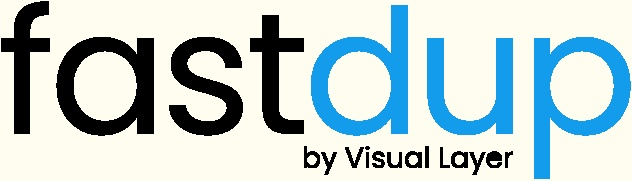
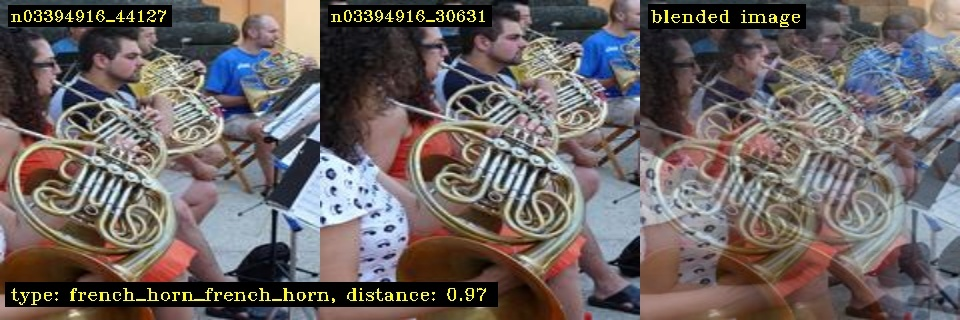
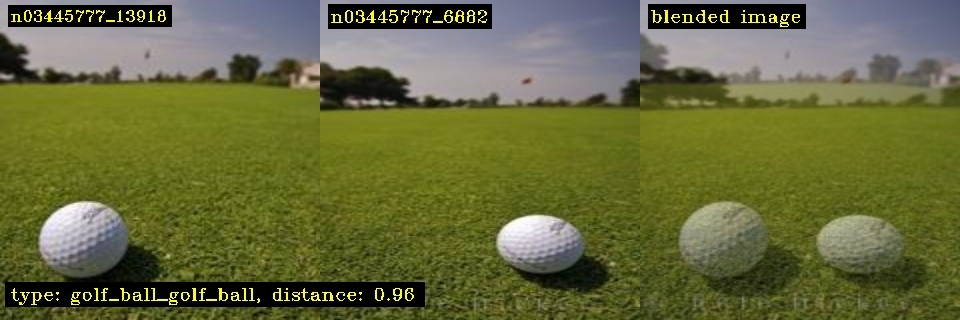
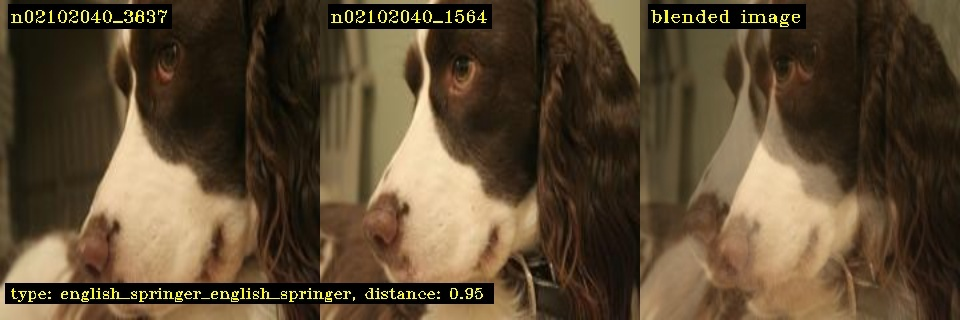

0

In [9]:
fd.vis.duplicates_gallery(num_images=5)

## Outliers

Similar to duplicate pairs, you can visualize potential outliers in your dataset with:

In [ ]:
fd.vis.outliers_gallery(num_images=5)

## Dark, Bright and Blurry Images

fastdup also lets you visualize images from your dataset using statistical metrics.

For example, with `metric='dark'` we can visualize the darkest images from the dataset.

In [ ]:
fd.vis.stats_gallery(metric="dark", num_images=5)

In [ ]:
fd.vis.stats_gallery(metric="bright", num_images=5)

In [ ]:
fd.vis.stats_gallery(metric="blur", num_images=5)

## Image Clusters

One of fastdup's coolest feature is visualizing image clusters. In the previous section we saw how to visualize similar image pairs. In this section we group similar looking image (or even duplicates) as a cluster and visualize them in gallery.

To do so, simply run:



> **Note**: fastdup uses default parameter values when creating image clusters. Depending on your data and use case, the best value may vary. Read more [here](https://visual-layer.readme.io/docs/dataset-cleanup) on how to change parameter values to cluster images.

In [ ]:
fd.vis.component_gallery(num_images=5)